# Titanic 데이터 실습

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(action="ignore")

In [3]:
# sibsp	# of siblings / spouses aboard the Titanic	
# parch	# of parents / children aboard the Titanic	
# ticket	Ticket number	
# fare	Passenger fare	
# cabin	Cabin number	
# embarked	Port of Embarkation

In [4]:
df = pd.read_csv("../../data_resources/titanic/train.csv")

df_raw = df.copy()

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna("N")

df["Cabin"] = df["Cabin"].fillna("N")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
df = df.drop(["Name", "PassengerId", "Ticket"], axis=1)

In [10]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,N,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,N,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,N,S


In [11]:
# from sklearn.preprocessing import LabelEncoder

# features = ["Sex", "Cabin", "Embarked"]

# for feature in features:
#     le = LabelEncoder()
#     df[feature] = le.fit_transform(df[feature])

# df.head()

In [12]:
from sklearn.preprocessing import LabelEncoder

gender_le = LabelEncoder()
df['Sex'] = gender_le.fit_transform(df["Sex"])

emb_le = LabelEncoder()
df["Embarked"] = emb_le.fit_transform(df["Embarked"])


In [13]:
df["Cabin"] = df["Cabin"].str[0]
cabin_le = LabelEncoder()
df["Cabin"] = cabin_le.fit_transform(df["Cabin"])

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,7.2500,7,3
1,1,1,0,38.0,1,0,71.2833,2,0
2,1,3,0,26.0,0,0,7.9250,7,3
3,1,1,0,35.0,1,0,53.1000,2,3
4,0,3,1,35.0,0,0,8.0500,7,3


In [15]:
# from sklearn.impute import SimpleImputer

# age_im = SimpleImputer(strategy="mean")

# embarked_im = SimpleImputer(strategy="constant", fill_value="N")

# cabin_im = SimpleImputer(strategy="constant", fill_value="N")

# df["Age"] = age_im.fit_transform(df[["Age"]]).ravel()

# df["Embarked"] = embarked_im.fit_transform(df[["Embarked"]]).ravel()

# df["Cabin"] = cabin_im.fit_transform(df[["Cabin"]]).ravel()

In [16]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()

df[["Age", "Fare"]] = mms.fit_transform(df[["Age", "Fare"]])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,0.271174,1,0,0.014151,7,3
1,1,1,0,0.472229,1,0,0.139136,2,0
2,1,3,0,0.321438,0,0,0.015469,7,3
3,1,1,0,0.434531,1,0,0.103644,2,3
4,0,3,1,0.434531,0,0,0.015713,7,3


In [17]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,0.367921,0.523008,0.381594,0.062858,5.946128,2.343434
std,0.486592,0.836071,0.477990,0.163383,1.102743,0.806057,0.096995,2.062347,1.167398
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,0.271174,0.000000,0.000000,0.015440,7.000000,2.000000
50%,0.000000,3.000000,1.000000,0.367921,0.000000,0.000000,0.028213,7.000000,3.000000
75%,1.000000,3.000000,1.000000,0.434531,1.000000,0.000000,0.060508,7.000000,3.000000
max,1.000000,3.000000,1.000000,1.000000,8.000000,6.000000,1.000000,8.000000,3.000000


## 이상치 제거

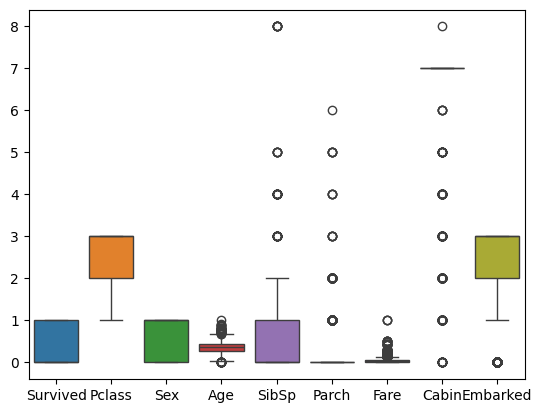

In [18]:
plt.figure()
sns.boxplot(df)
plt.show()  

In [19]:
q1 = df["Fare"].quantile(0.25)
q3 = df["Fare"].quantile(0.75)

iqr = q3 - q1

lower = q1 - (iqr * 1.5)
upper = q3 + (iqr * 1.5)

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  775 non-null    int64  
 1   Pclass    775 non-null    int64  
 2   Sex       775 non-null    int64  
 3   Age       775 non-null    float64
 4   SibSp     775 non-null    int64  
 5   Parch     775 non-null    int64  
 6   Fare      775 non-null    float64
 7   Cabin     775 non-null    int64  
 8   Embarked  775 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 60.5 KB


<Axes: xlabel='Sex', ylabel='Survived'>

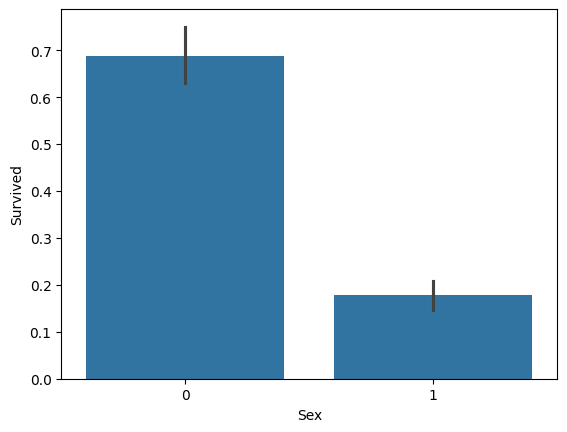

In [20]:
sns.barplot(x='Sex', y="Survived", data=df)

<Axes: xlabel='Pclass', ylabel='Survived'>

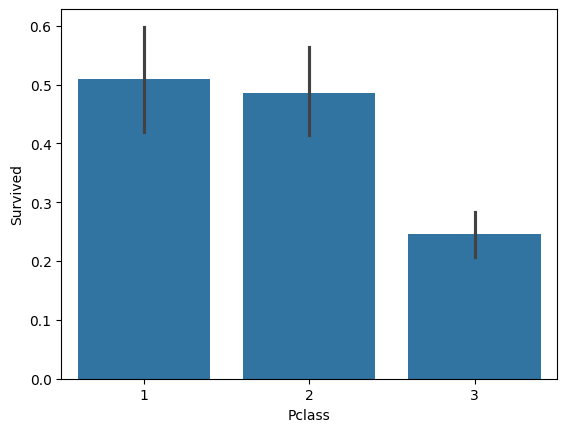

In [21]:
sns.barplot(x='Pclass', y="Survived", data=df)

<Axes: xlabel='Pclass', ylabel='Survived'>

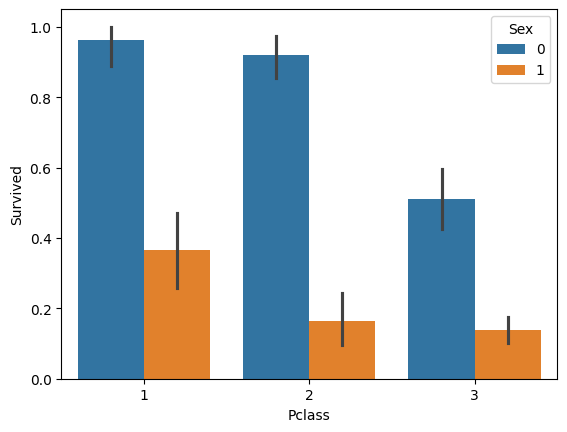

In [22]:
sns.barplot(x='Pclass', y="Survived", hue="Sex", data=df)

<Axes: xlabel='Survived', ylabel='count'>

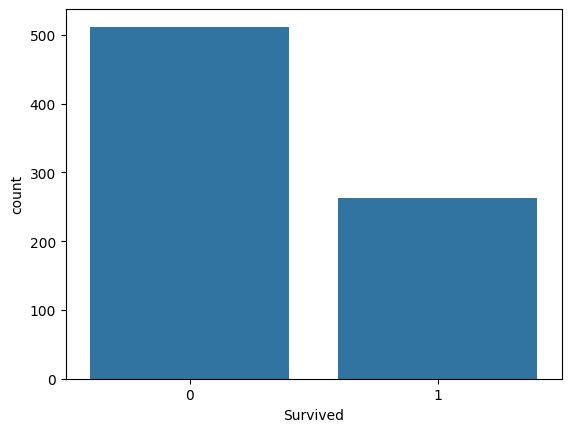

In [23]:
sns.countplot(x="Survived", data=df)

In [24]:
from sklearn.model_selection import train_test_split

x = df.drop("Survived", axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(620, 8)
(155, 8)
(620,)
(155,)


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

dt = DecisionTreeClassifier()

rf = RandomForestClassifier()

lr = LogisticRegression()

dt.fit(x_train, y_train)
rf.fit(x_train, y_train)
lr.fit(x_train, y_train)

print("Decision Tree accuracy:", dt.score(x_test, y_test))
print("Random Forest accuracy:", rf.score(x_test, y_test))
print("Logistic Regression accuracy:", lr.score(x_test, y_test))


Decision Tree accuracy: 0.7806451612903226
Random Forest accuracy: 0.8129032258064516
Logistic Regression accuracy: 0.7870967741935484


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

rf = RandomForestClassifier()
rf.fit(x_train, y_train)

score = rf.score(x_test, y_test)
print(score)

0.8


In [27]:
y_pred = rf.predict(x_test)

print("정확도: ", score)
print("정밀도:", precision_score(y_test, y_pred))
print("민감도:", recall_score(y_test, y_pred))
print("f1 스코어:", f1_score(y_test, y_pred))

정확도:  0.8
정밀도: 0.7291666666666666
민감도: 0.660377358490566
f1 스코어: 0.693069306930693


# 펭귄 CSV

In [28]:
df = pd.read_csv("../../data_resources/penguins_size.csv")

df_raw = df.copy()

In [29]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [31]:
df["sex"] = df.sex.fillna("Unknown")


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["species"] = le.fit_transform(df["species"])

le = LabelEncoder()
df['island'] = le.fit_transform(df['island'])

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,2
1,0,2,39.5,17.4,186.0,3800.0,1
2,0,2,40.3,18.0,195.0,3250.0,1
3,0,2,NaN,NaN,NaN,NaN,3
4,0,2,36.7,19.3,193.0,3450.0,1


In [33]:
df[["species", "island"]].head(100)

df['species'].unique()

array([0, 1, 2])

In [34]:
df.dropna(inplace=True)

In [35]:
from sklearn.model_selection import train_test_split

x = df.drop("species", axis=1)
y = df["species"]

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(273, 6)
(69, 6)
(273,)
(69,)


In [36]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(x_train, y_train)

score = dt.score(x_test, y_test)
print(score)

0.9855072463768116


In [37]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
gb = GradientBoostingClassifier()

gb.fit(x_train, y_train)

y_pred = gb.predict(x_test)

print("accuracy" , gb.score(x_test, y_test))
print("precision_score", precision_score(y_test, y_pred, average="weighted"))
print("recall", recall_score(y_test, y_pred, average="weighted"))
print("f1_score", f1_score(y_test, y_pred, average="weighted"))

accuracy 1.0
precision_score 1.0
recall 1.0
f1_score 1.0


In [41]:
import lightgbm as lgb

train_data = lgb.Dataset(x_train, label=y_train)

params = {
    "objective": "multiclass",
    "num_class": 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 00.5
}

model = lgb.train(params, train_data, num_boost_round=100)

y_pred = model.predict(x_test)
y_pred_class = y_pred.argmax(axis=1)

accuracy = accuracy_score(y_test, y_pred_class)
precision = precision_score(y_test, y_pred_class, average="weighted")
recall = recall_score(y_test, y_pred_class, average="weighted")
f1 = f1_score(y_test, y_pred_class, average="weighted")

print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1_score:", f1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 241
[LightGBM] [Info] Number of data points in the train set: 273, number of used features: 6
[LightGBM] [Info] Start training from score -0.813681
[LightGBM] [Info] Start training from score -1.620488
[LightGBM] [Info] Start training from score -1.024504
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 